In [1]:
import sys
import json
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from cmcrameri import cm
from matplotlib.ticker import MultipleLocator

sys.path.append("scripts/utils/")
from Microscopes         import Tomocube, Holomonitor
from signal_filtering import apply_lowpass
from SegmentedCells import SegmentedCells

data_path = "../../../../hdd_data/silja/Monolayers/"

In [33]:
min_hours = 8
n0 = Tomocube().n0
alpha = 0.19

In [34]:
# Plot settings
lw = 2

h_color = "b"
A_color = "orange"
V_color = "tab:green"
c_color = 'k'

font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 14}

mpl.rc('font', **font)

In [65]:
# import dataset
dataset = "MDCK_20250904_B1-1"
config = json.load(open(f"configs/{dataset}.json"))

### SET MICROSCOPE ###
if config['microscope'] == "holomonitor": microscope = Holomonitor()
elif config['microscope'] == "tomocube":  microscope = Tomocube()


cells = SegmentedCells(f"{data_path}cell_features/calibrated/{dataset}_cells.p")

# keep only long tracks
min_track = min_hours / microscope.frame_to_h

long_mask = (np.ma.sum(~cells.A.mask, axis=0) > min_track)
good_cells = np.arange(len(long_mask))[long_mask]
print(f"Number of good tracks: {len(good_cells)}")

# apply lowpass filter to data. area is the only parameter directly related to segmentation, but since also 
# the average height and average refractive index depends on the area, we also filter these
area_lowpass   = apply_lowpass(cells.A, cells.A.mask, cutoff=0.8, fs=1/microscope.frame_to_h, order=6)
height_lowpass = apply_lowpass(cells.h, cells.h.mask, cutoff=0.8, fs=1/microscope.frame_to_h, order=6)
if microscope.name == "tomocube":
    c_lowpass      = apply_lowpass(cells.n, cells.n.mask, cutoff=0.8, fs=1/microscope.frame_to_h, order=6)
    c_lowpass      = (c_lowpass - n0) / alpha
else:
    c_lowpass = np.zeros_like(area_lowpass)


# remove short tracks and last data points
heights   = height_lowpass[:,good_cells]
areas     = area_lowpass[:,good_cells]
volumes   = (height_lowpass * area_lowpass)[:,good_cells]
drymass   = c_lowpass[:,good_cells]
hours     = np.arange(len(cells.x[:,0])) * microscope.frame_to_h

State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20250904_B1-1_cells.p.
Number of good tracks: 27


### Plot area and height tracks

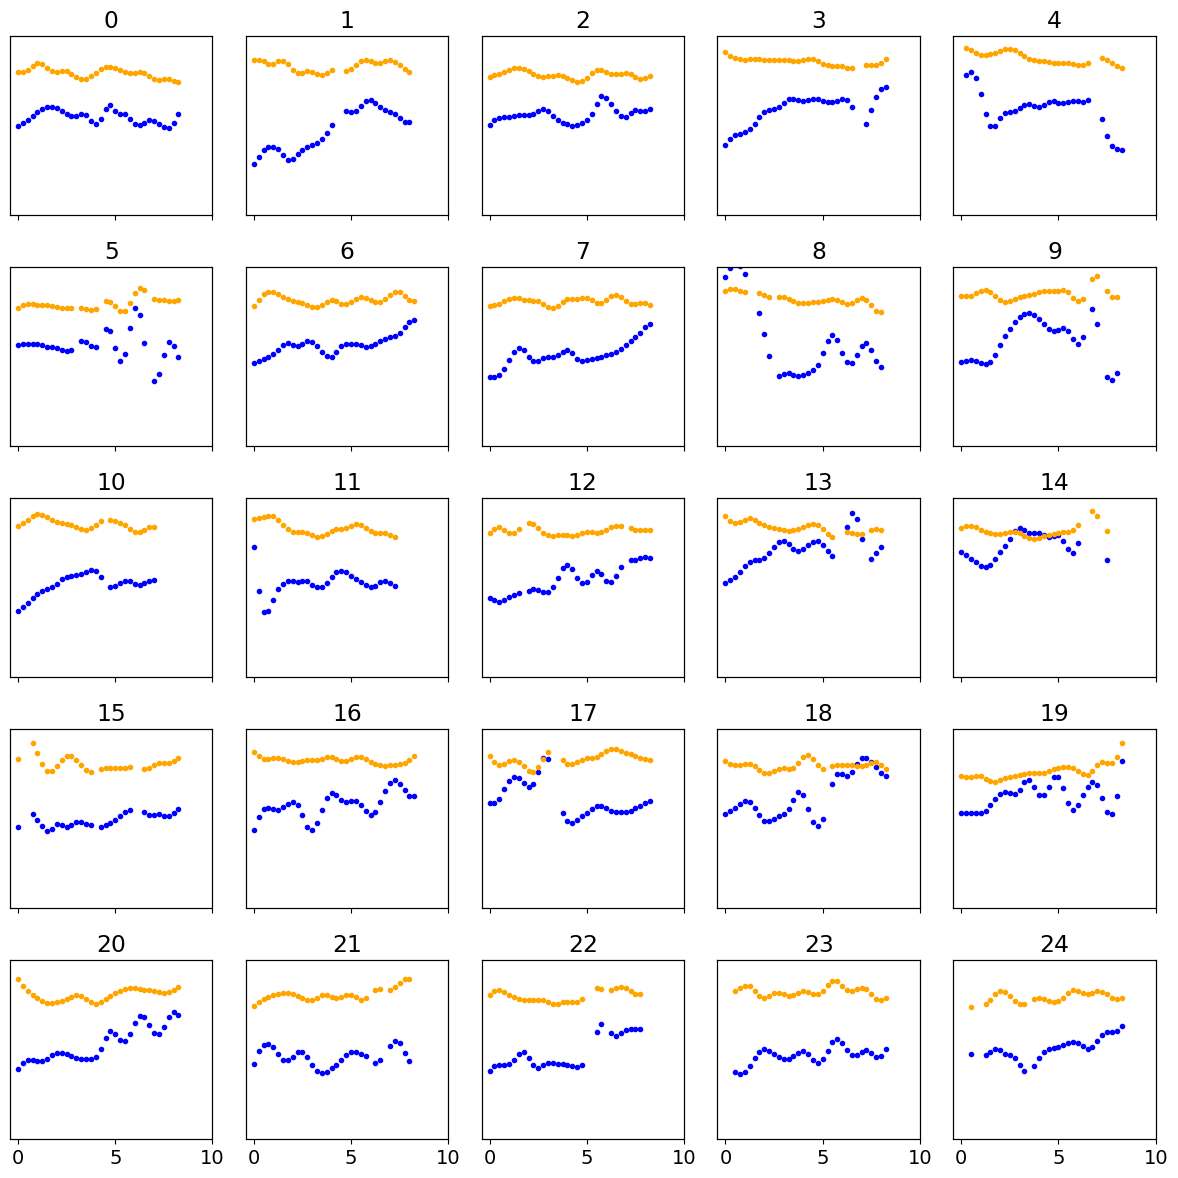

In [66]:
# sns.set_theme(style='ticks', palette='bright', font_scale=0.8)
fig, axes = plt.subplots(5,5, figsize=(12,12), sharex=True)#, sharey=True)


i = 0
for ax in axes.flatten():

    # twin axis for volume fraction
    ax1 = ax.twinx()

   
    # plot volume
    cell_height = volumes[:,i]
    cell_area   = drymass[:,i]

    time        = hours[~cell_height.mask]
    cell_area   = cell_area[~cell_height.mask]
    cell_height = cell_height[~cell_height.mask]

    cell_drymass = drymass[:,i]

    ax .plot(time[:-5], cell_height[:-5], '.', c=h_color)
    ax1.plot(time[:-5], cell_area[:-5], '.', c=A_color)




    # axes specifications
    ax1.set_yticks([])
    ax.set_yticks([])
    

    ax1.set(ylim=(0,0.15))
    ax .set(ylim=(0,6000))
    ax .set(title=i)
    ax .set_xticks([0, 5, 10])
    ax.tick_params(axis='y',  labelcolor=h_color)
    ax1.tick_params(axis='y', labelcolor=A_color)



    i += 1


fig.tight_layout()


In [67]:
plot_idx = [12, 16, 2,
            1, 7, 21, 
            23, 6, 20]
# plot_idx = [0, 7, 9, 27, 15, 30, 25, 13, 22]



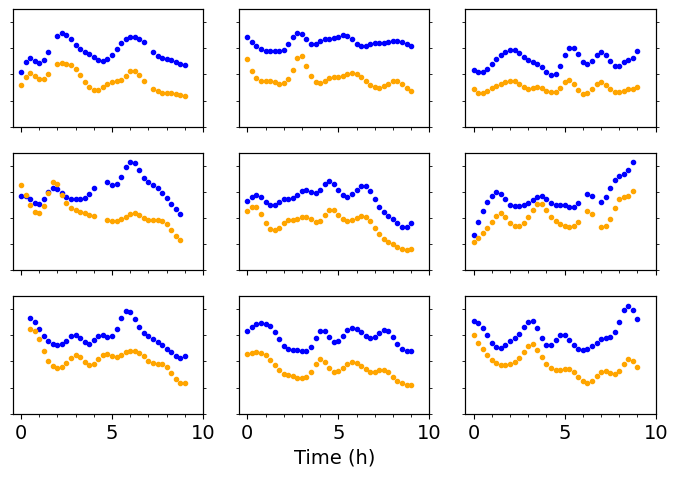

In [71]:

# sns.set_theme(style='ticks', palette='bright', font_scale=0.8)
fig, axes = plt.subplots(3,3, figsize=(7,5), sharex=True)#, sharey=True)

i = 0
for ax, idx in zip(axes.flatten(), plot_idx):

    # twin axis for volume fraction
    ax1 = ax.twinx()

   
    # plot volume
    cell_height = heights[:,idx]
    cell_area   = areas[:,idx]

    time        = hours[~cell_height.mask]
    cell_area   = cell_area[~cell_height.mask]
    cell_height = cell_height[~cell_height.mask]

    ax .plot(time[:-2], cell_height[:-2], 'o',  c=h_color, lw=lw, ms=3)
    ax1.plot(time[:-2], 1/cell_area[:-2], 'o', c=A_color,  lw=lw, ms=3)




    # axes specifications
    #if (i+1)%3 != 0:
    ax1.set_yticks([])
    # #if (i)%3 != 0:
    ax.set_yticks([])
    #if i==5:
        #ax1.set(ylabel=r"A$^{-1}$ (µm$^{-2}$)")

    ax1.set(ylim=(0,0.0045))
    ax .set(ylim=(0,9))
    ax .set_xticks([0, 5, 10])
    ax.tick_params(axis='y', labelcolor=h_color)
    ax1.tick_params(axis='y', labelcolor=A_color)
    ax .yaxis.label.set_color(h_color)
    ax1.yaxis.label.set_color(A_color)
    ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.set_minor_locator(MultipleLocator(2))
    #ax.yaxis.set_major_locator(MultipleLocator(5))
    ax1.yaxis.set_minor_locator(MultipleLocator(1e-3))
    #ax1.yaxis.set_major_locator(MultipleLocator(2.5e-3))

    i += 1

plt.minorticks_on()
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)

#axes[1,0].set(ylabel="h (µm)")
axes[2,1].set(xlabel="Time (h)")
fig.tight_layout()
fig.savefig("figs/Elife/subfigures/hA_tracks.svg", format="svg")


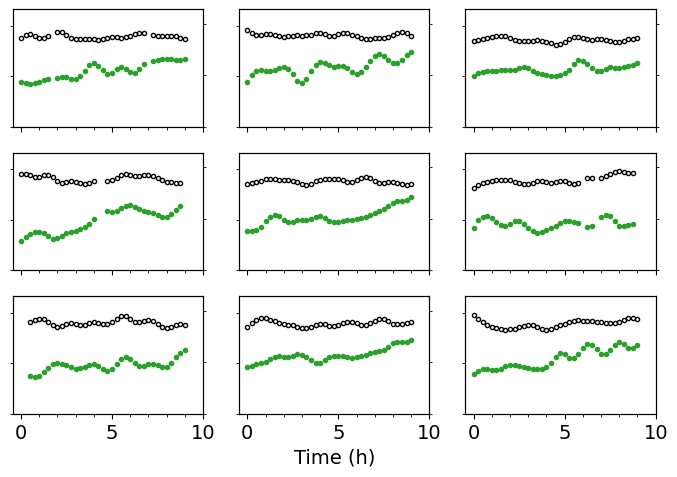

In [69]:
# sns.set_theme(style='ticks', palette='bright', font_scale=0.8)
fig, axes = plt.subplots(3,3, figsize=(7,5), sharex=True)#, sharey=True)

i = 0
for ax, idx in zip(axes.flatten(), plot_idx):

    # twin axis for volume fraction
    ax1 = ax.twinx()

   
    # plot volume
    cell_volume  = volumes[:,idx]
    cell_drymass = drymass[:,idx]

    time         = hours[~cell_volume.mask]
    cell_drymass = cell_drymass[~cell_volume.mask]
    cell_volume  = cell_volume[~cell_volume.mask]

    ax .plot(time[:-2], cell_volume[:-2],  'o', c=V_color, lw=1, ms=3)#, fillstyle="none")
    ax1.plot(time[:-2], cell_drymass[:-2], 'o', c=c_color, lw=1, ms=3, fillstyle="none")




    # axes specifications
    #if (i+1)%3 != 0:
    ax1.set_yticks([])
    #if (i)%3 != 0:
    ax.set_yticks([])

    ax1.set(ylim=(0,0.16))
    ax .set(ylim=(0,7000))
    ax .set_xticks([0, 5, 10])
    ax.tick_params(axis='y',  labelcolor=V_color)
    ax1.tick_params(axis='y', labelcolor=c_color)
    # ax .yaxis.label.set_color(h_color)
    # ax1.yaxis.label.set_color(A_color)
    ax .ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax .yaxis.set_minor_locator(MultipleLocator(3e3))
    ax1.yaxis.set_minor_locator(MultipleLocator(7e-2))

    i += 1

plt.minorticks_on()
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)

#axes[1,0].set(ylabel="h (µm)")
axes[2,1].set(xlabel="Time (h)")
fig.tight_layout()
fig.savefig("figs/Elife/subfigures/vV_tracks.svg", format="svg")


In [70]:
np.ma.mean(np.ma.std(drymass, axis=0) / np.ma.mean(drymass, axis=0)) * 100, np.ma.mean(np.ma.std(c_lowpass, axis=0) / np.ma.mean(c_lowpass, axis=0)) * 100

(np.float64(3.830119578637875), np.float64(1.470313767565033))